# Outlier detection and removal using Z-score method

## <span style="color:red">Assumption: The data is normally distributed.</span>

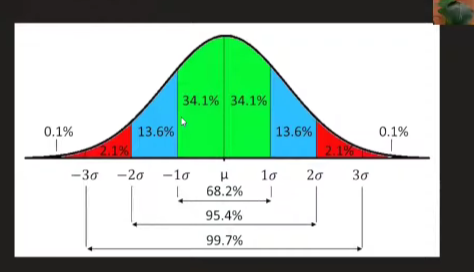

- In the range of mean ± 1 standard deviation, there are 68% of the data points.
- In the range of mean ± 2 standard deviations, there are 95% of the data points.
- In the range of mean ± 3 standard deviations, there are 99.7% of the data points.

- So beyond the range of mean ± 3 standard deviations, there are only 0.3% of the data points, which are considered as outliers.


# Z-Score and Range Check for Outlier Detection

## <span style="color:orange">1. Z-Score Definition</span>
The Z-score standardizes a data point relative to the mean and standard deviation.

Formula:
z = (x - μ) / σ

Where:
- x = data point  
- μ = mean  
- σ = standard deviation  

---

## <span style="color:orange">2. Range-Based Outlier Detection</span>
In a normal distribution:
- ~68% of data lies within μ ± 1σ  
- ~95% within μ ± 2σ  
- ~99.7% within μ ± 3σ  

Outlier condition:
x < (μ - 3σ) OR x > (μ + 3σ)

---

## <span style="color:orange">3. Z-Score Based Outlier Detection</span>
Using Z-score:
- Convert x into standardized value z  
- Check if z lies within range  

Outlier condition:
z < -3 OR z > 3

---

## <span style="color:orange">4. Equivalence of Both Methods</span>

Range method:
μ - 3σ ≤ x ≤ μ + 3σ  

Divide entire inequality by σ:
(x - μ) / σ ∈ [-3, 3]

Since:
z = (x - μ) / σ  

Therefore:
-3 ≤ z ≤ 3  

Thus, both methods are mathematically equivalent.

---

## <span style="color:orange">5. Key Insight</span>
- Range method works in original data scale  
- Z-score method works in standardized scale  
- Both identify the same outliers  

---

## <span style="color:orange">6. Example</span>
Given:
μ = 50, σ = 10  

Range:
20 ≤ x ≤ 80  

For x = 90:
z = (90 - 50) / 10 = 4  

Since z > 3 → Outlier  
Since x > 80 → Outlier  

Both methods give the same result.

---

## <span style="color:orange">7. Conclusion</span>
Z-score checking is simply a normalized version of range checking.  
They are equivalent approaches for detecting outliers.

# Outlier Treatment:
1. Trim the outliers (remove them from the dataset)
2. Capping (replace outliers with μ + 3σ or μ - 3σ)

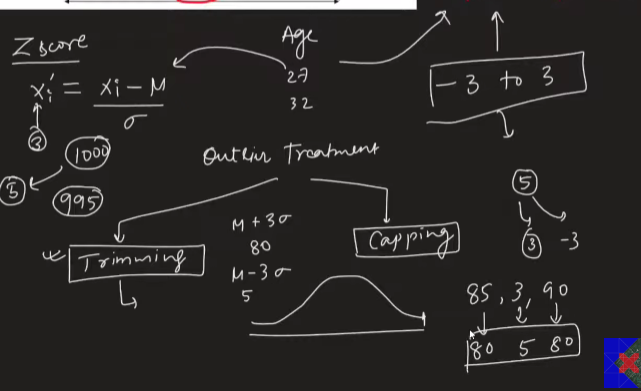

# <span style="color:lightgreen">Final steps:</span>

<ol style="color:magenta;">
<li>Check if the data is normally distributed (e.g., using histogram, Q-Q plot, or normality tests).</li>
<li>Find mean and standard deviation.</li>
<li>Calculate Z-scores for each data point. If Z-score is beyond ±3, treat it as an outlier (either trim or cap).</li>
</ol>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.shape

(1000, 3)

In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
532,6.90,20.0,0
149,6.81,58.0,0
9,7.75,94.0,1
960,6.81,10.0,1
234,8.09,36.0,0


C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_5744\3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_5744\3792736820.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


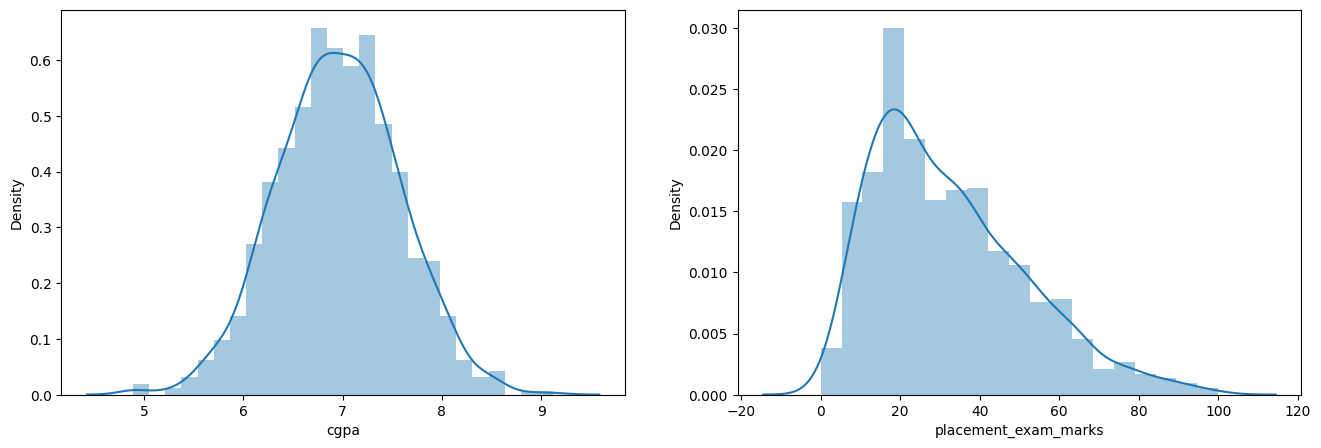

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

- cgpa is normally distributed
- placement marks are not normally distributed

so we can apply Z-score method for cgpa but not for placement marks.

In [6]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [7]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [8]:
# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [9]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


So these 5 are outliers if we apply Z-score method on cgpa.

## Trimming

In [10]:
# Trimming

new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [11]:
# Approach 2

# Calculating the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [12]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [13]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [14]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [15]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [16]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [17]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Capping

In [18]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [19]:
lower_limit

np.float64(5.113546374602832)

```
np.where(x,y,z)
```

- where x is the condition, y is the value if condition is true, and z is the value if condition is false.

In [ ]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [21]:
df.shape

(1000, 4)

In [22]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64